In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pyreadr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn import set_config

# Configuración de visualización
set_config(display='diagram')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

SEED = 123
np.random.seed(SEED)

In [2]:
# Ajustar la ruta al archivo según corresponda
RUTA_DATOS = 'listings.RData'

resultado = pyreadr.read_r(RUTA_DATOS)
df = resultado['listings']

print(f"Dimensiones originales: {df.shape}")
print(f"Cantidad de variables: {df.shape[1]}")
df.head()

Dimensiones originales: (171748, 80)
Cantidad de variables: 80


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
# Ver los tipos de variables
print("Distribución de tipos de datos:")
print(df.dtypes.value_counts())
# Distribución por ciudad
print("\nListings por ciudad:")
print(df['city'].value_counts())

Distribución de tipos de datos:
object     47
int32      18
float64    16
Name: count, dtype: int64

Listings por ciudad:
city
Los Angeles, California      45585
New York, New York           36261
Hawaii                       33457
San Diego, California        13162
Austin, Texas                10533
Chicago, Illinois             8660
San Francisco, California     7535
Washington, D.C.              6374
Rhode Island                  5762
Boston, Massachusetts         4419
Name: count, dtype: int64


In [3]:
df['price_num'] = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

print("Estadísticas de price_num:")
print(df['price_num'].describe())
print(f"\nNulos en price: {df['price_num'].isna().sum()} "
      f"({df['price_num'].isna().mean()*100:.1f}%)")

Estadísticas de price_num:
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price_num, dtype: float64

Nulos en price: 95502 (55.6%)


In [5]:
# Nulos de precio por ciudad
print("Porcentaje de precios nulos por ciudad:")
nulos_ciudad = df.groupby('city')['price_num'].apply(
    lambda x: x.isna().mean()*100
).sort_values(ascending=False)
print(nulos_ciudad.round(2))

Porcentaje de precios nulos por ciudad:
city
Los Angeles, California      100.00
New York, New York           100.00
San Francisco, California    100.00
Washington, D.C.              23.25
Boston, Massachusetts         20.66
San Diego, California         13.53
Rhode Island                  13.35
Chicago, Illinois              9.64
Hawaii                         0.97
Austin, Texas                  0.15
Name: price_num, dtype: float64


In [6]:
# Filtrar registros con precio válido
df = df[df['price_num'].notna()].copy()
print(f"Dimensiones tras filtrar nulos de precio: {df.shape}")

Dimensiones tras filtrar nulos de precio: (76246, 81)


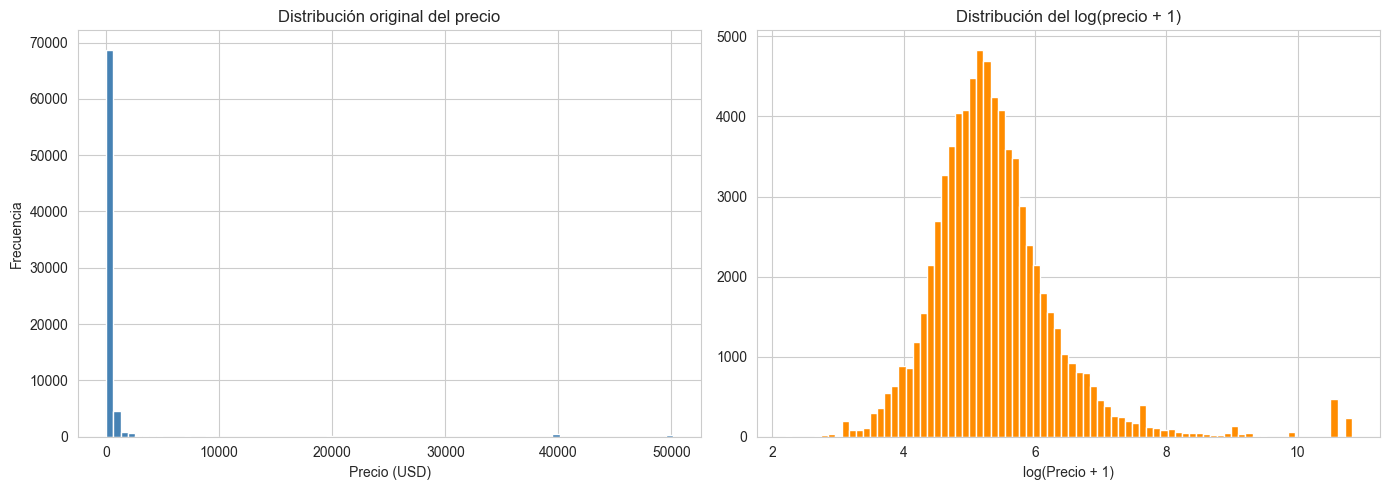

Skewness original: 9.87


In [7]:
## Distribución de precios por ciudad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price_num'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución original del precio')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['price_num']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución del log(precio + 1)')
axes[1].set_xlabel('log(Precio + 1)')
plt.tight_layout()
plt.show()

print(f"Skewness original: {df['price_num'].skew():.2f}")